In [16]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../../sampler-evaluation/')
from sampler_evaluation.models.student_t import StudentT, Power


plt.style.use('../../style.mplstyle')
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.size'] = 16


#model_name = 'StudentT'
model_name = 'Power'

def get_names(model_name):
    if model_name == 'StudentT':
        dofs1 = np.arange(3, 3 + 8)
        dofs2 = np.floor(np.geomspace(12, 50, 8)).astype(int)
        dofs = np.concatenate((dofs1, dofs2))

        names = [f"Student-t_dof={dof}" for dof in dofs]

        return dofs, names

    elif model_name == 'Power':
        p = np.arange(2, 10)
        names = [f"Power_{pp}" for pp in p]

        return p, names
    else:
        raise ValueError


eevpd_target = 1e-3

scratch = '/pscratch/sd/j/jrobnik/bias/'


for i in [0, 7]:
    name = get_names(model_name)[1][i]
    
    X = np.load(scratch + name + '.npz')
    
    plt.figure(figsize = (15, 4))
    
    plt.subplot(1, 2, 1)
    plt.title(name)
    
    for x in X['bias']:
        plt.plot(x, alpha = 0.5, color = 'grey')

    plt.plot(np.median(X['bias'], axis = 0), color = 'teal')

    plt.yscale('log')
    plt.xlabel('iterations')
    plt.ylabel(r'$b_{cov}^2$')
    
    plt.subplot(1, 2, 2)
    
    plt.hist(X['eevpd'] / eevpd_target, bins = 10)

    plt.xlabel('EEVPD / EEVPD (target)')

    plt.show()


EOFError: No data left in file

In [5]:
from scipy.optimize import brentq
b_root = brentq(lambda b: 4 * b**3 / (1 + b)**2 - eevpd_target, 0.01, 0.1)
b_root

0.06572702713685365

EOFError: No data left in file

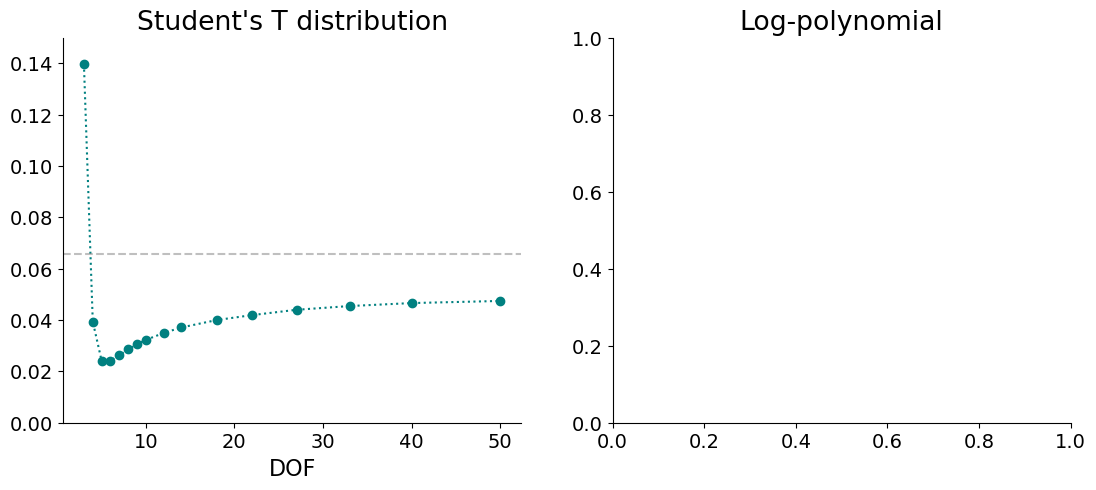

In [17]:

def get_data(names):
    
    bias = []
    
    for name in names:

        X = np.load(scratch + name + '.npz')
        bias.append(np.median(X['bias'][:, -1]))
    
    return np.sqrt(bias)


plt.figure(figsize = (13, 5))
plt.subplot(1, 2, 1)
params, names = get_names('StudentT')

bias = get_data(names)
plt.plot(params, bias, 'o:', color= 'teal')
plt.axhline(b_root, ls= '--', color = 'grey', alpha= 0.5)
plt.title("Student's T distribution")
plt.ylim(0, 0.15)
plt.xlabel('DOF')

plt.subplot(1, 2, 2)
plt.title('Log-polynomial')

params, names = get_names('Power')
bias = get_data(names)
plt.plot(params, bias, 'o:', color= 'teal')
plt.axhline(b_root, ls= '--', color = 'grey', alpha= 0.5)
plt.ylim(0, 0.15)
plt.xlim(2, 9.3)
plt.xlabel('power')

plt.tight_layout()
plt.show()